# Install Dependencies

In [1]:
!pip install ultralytics torch torchvision
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
!pip install scikit-learn pyyaml

# Import Dataset

In [ ]:
# Dataset: https://universe.roboflow.com/roboflow-100/brain-tumor-m2pbp/dataset/2

# from roboflow import Roboflow
# rf = Roboflow(api_key="agKqaclXeu78vq208RIw")
# project = rf.workspace("roboflow-100").project("brain-tumor-m2pbp")
# version = project.version(2)
# dataset = version.download("yolo26")

In [ ]:
# Dataset: https://universe.roboflow.com/braintumordetectoin/brain-tumor-detection-s98xn/dataset/1

# from roboflow import Roboflow
# rf = Roboflow(api_key="agKqaclXeu78vq208RIw")
# project = rf.workspace("braintumordetectoin").project("brain-tumor-detection-s98xn")
# version = project.version(1)
# dataset = version.download("yolo26")


In [3]:
# Dataset: https://universe.roboflow.com/brain-tumor-0nuhu/yolo-brain-tumor-7qogu

from roboflow import Roboflow
rf = Roboflow(api_key="agKqaclXeu78vq208RIw")
project = rf.workspace("brain-tumor-0nuhu").project("yolo-brain-tumor-7qogu")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to yolo-brain-tumor--1 in yolo26:: 100%|██████████| 6137/6137 [00:01<00:00, 4140.03it/s]


# Spliting dataset

In [4]:
# Install if needed
  # pyyaml for safe YAML writing

# Imports
import os
from sklearn.model_selection import train_test_split
from pathlib import Path
import shutil
import yaml  # For creating YAML
import random

# Set paths (UPDATE TO YOUR DOWNLOADED FOLDER)
data_dir = Path('/content/yolo-brain-tumor--1')  # e.g., unzipped Roboflow folder with 'train/images' and 'train/labels'
output_dir = Path('/content/Brain-tumor-detection-new')
random.seed(42)  # For reproducibility

# Create output structure
for split in ['train', 'valid', 'test']:
    (output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
    (output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

# Get all image paths (assume from 'train/images')
image_paths = list((data_dir / 'train' / 'images').glob('*'))  # .jpg, .png, etc.
print(f"Found {len(image_paths)} images to split.")

# Split: 70% train, 20% val, 10% test
train_imgs, temp_imgs = train_test_split(image_paths, test_size=0.3, random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=1/3, random_state=42)  # ~0.1 of total

splits_map = {'train': train_imgs, 'valid': val_imgs, 'test': test_imgs}

# Copy images + corresponding labels
for split_name, img_list in splits_map.items():
    for img_path in img_list:
        img_name = img_path.name
        # Copy image
        shutil.copy2(img_path, output_dir / split_name / 'images' / img_name)

        # Copy label (same name, .txt)
        label_path = img_path.parent.parent / 'labels' / img_name.replace('.jpg', '.txt').replace('.png', '.txt')  # Adjust extension if needed
        target_label = output_dir / split_name / 'labels' / label_path.name
        if label_path.exists():
            shutil.copy2(label_path, target_label)
        else:
            # Create empty label if none (handles missing annotations)
            target_label.write_text('')  # Empty file

# Stats
for split in ['train', 'valid', 'test']:
    num_imgs = len(list((output_dir / split / 'images').glob('**/*')))
    print(f"{split}: {num_imgs} images")

# Step: Auto-create dataset.yaml INSIDE output_dir
yaml_path = output_dir / 'dataset.yaml'
yaml_content = {
    'path': str(output_dir),  # Root path (auto-resolves in YOLO)
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 3,  # Number of classes (update to 4 if adding no_tumor)
    'names': ['glioma', 'meningioma', 'pituitary']  # Class names (update as needed)
}

# Write YAML
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"\nCreated YAML config: {yaml_path}")
print("YAML contents:")
for key, value in yaml_content.items():
    print(f"  {key}: {value}")

# Zip for download (optional)
# !zip -r /content/split_dataset.zip /content/split_dataset
# from google.colab import files
# files.download('/content/split_dataset.zip')
# print("Downloaded: split_dataset.zip (includes dataset.yaml)")

Found 2145 images to split.
train: 1501 images
valid: 429 images
test: 215 images

Created YAML config: /content/Brain-tumor-detection-new/dataset.yaml
YAML contents:
  path: /content/Brain-tumor-detection-new
  train: train/images
  val: valid/images
  test: test/images
  nc: 3
  names: ['glioma', 'meningioma', 'pituitary']


# Initialize paths

In [5]:
import os
import torch
from ultralytics import YOLO
import yaml

# Step 1: Set path for the single active dataset
dataset_path = '/content/Brain-tumor-detection-new'
save_dir = './brain_tumor_single_train'
model_save_path = os.path.join(save_dir, 'brain_tumor_model.pt')

# Verify path exists
if not os.path.exists(dataset_path):
    raise ValueError(f"Dataset path not found: {dataset_path}. Download and unzip first.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# # Step 2: Create single-dataset YAML config
# yaml_content = {
#     'train': os.path.join(dataset_path, 'train'),
#     'val': os.path.join(dataset_path, 'valid'),
#     'test': os.path.join(dataset_path, 'test'),
#     'nc': 3,
#     'names': ['glioma', 'meningioma', 'pituitary']
# }

# # Write YAML to file
# yaml_path = 'brain_tumor.yaml'
# with open(yaml_path, 'w') as f:
#     yaml.dump(yaml_content, f)
# print(f"Created dataset YAML: {yaml_path}")

# Train the Model

In [6]:
yaml_path = '/content/Brain-tumor-detection-new/dataset.yaml'
# Step 3: Load pretrained model and train
model = YOLO('yolo26m.pt')  # Nano for speed; use 'yolov8m.pt' for better accuracy

# Train with early stopping for overfitting
results = model.train(
    data=yaml_path,
    epochs=120,  # Enough epochs; stops early if overfitting
    imgsz=640,   # Matches Dataset 1 preprocessing
    batch=16,    # Adjust based on GPU memory (e.g., 8 for smaller GPUs)
    device=0,    # GPU; set to 'cpu' if no GPU
    patience=20, # Stop if no improvement for 20 epochs (anti-overfitting)
    save=True,   # Save checkpoints
    project=save_dir,  # Custom run dir
    name='multi_train_yolo26',  # Run name
    plots=True,  # Save training plots (loss curves, etc.)
    verbose=True  # Print progress
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Brain-tumor-detection-new/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=multi_train_yolo26, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

# Display Results

In [7]:
# Step 4: Display results
print("\n=== Training Results ===")

# Let's see what keys are actually available to avoid further KeyErrors
print("Available metrics keys:", results.results_dict.keys())

# Use .get() to avoid crashing if a specific key is missing
map50 = results.results_dict.get('metrics/mAP50(B)', 0)
map95 = results.results_dict.get('metrics/mAP50-95(B)', 0)

print(f"Final mAP@0.5: {map50:.4f}")
print(f"Final mAP@0.5:0.95: {map95:.4f}")

# Step 5: Custom save
os.makedirs(save_dir, exist_ok=True)

trainer = model.trainer
last_epoch = trainer.epoch - 1 if trainer.epoch > 0 else 0

checkpoint = {
    'epoch': last_epoch,
    'model_state_dict': model.model.state_dict(),
    'optimizer_state_dict': trainer.optimizer.state_dict() if trainer.optimizer else None,
    'metrics': results.results_dict,
    'loss': map50  # Final val loss
}

torch.save(checkpoint, model_save_path)
print(f"Custom checkpoint saved: {model_save_path}")

# Step 6: Export for deployment
model.export(format='onnx')

# Optional: Validate
val_results = model.val(data=yaml_path)
print("Test mAP@0.5:", val_results.box.map50)


=== Training Results ===
Available metrics keys: dict_keys(['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'fitness'])
Final mAP@0.5: 0.9310
Final mAP@0.5:0.95: 0.7036
Custom checkpoint saved: ./brain_tumor_single_train/brain_tumor_model.pt
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs

PyTorch: starting from '/content/runs/detect/brain_tumor_single_train/multi_train_yolo26/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (42.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 190ms
Prepar

Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 12.8s, saved as '/content/runs/detect/brain_tumor_single_train/multi_train_yolo26/weights/best.onnx' (77.9 MB)

Export complete (15.5s)
Results saved to /content/runs/detect/brain_tumor_single_train/multi_train_yolo26/weights
Predict:         yolo predict task=detect model=/content/runs/detect/brain_tumor_single_train/multi_train_yolo26/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/brain_tumor_single_train/multi_train_yolo26/weights/best.onnx imgsz=640 data=/content/Brain-tumor-detection-new/dataset.yaml  
Visualize:       https://netron.app
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1541.5±534.8 MB/s, size: 31.3 KB)
val: Scanning /content/Brain-tumor-detection-new/valid/labels.cache... 429 images, 0 backg

In [8]:
# confusion matrix
model = YOLO("/content/runs/detect/brain_tumor_single_train/multi_train_yolo26/weights/best.pt")
results = model.val(data='/content/Brain-tumor-detection-new/dataset.yaml')
confusion_matrix_data = results.confusion_matrix

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1294.6±381.1 MB/s, size: 31.4 KB)
val: Scanning /content/Brain-tumor-detection-new/valid/labels.cache... 429 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 429/429 199.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.6it/s 16.5s
                   all        429        429      0.947      0.839      0.933      0.703
                glioma        187        187      0.882      0.711      0.839      0.527
            meningioma        105        105      0.968      0.914      0.982      0.833
             pituitary        137        137      0.992       0.89      0.978       0.75
Speed: 1.6ms preprocess, 33.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs

# Testing Model Manually

Upload your external MRI image:


Saving G_images.jpg to G_images (4).jpg
Model loaded! Classes: glioma, meningioma, pituitary.


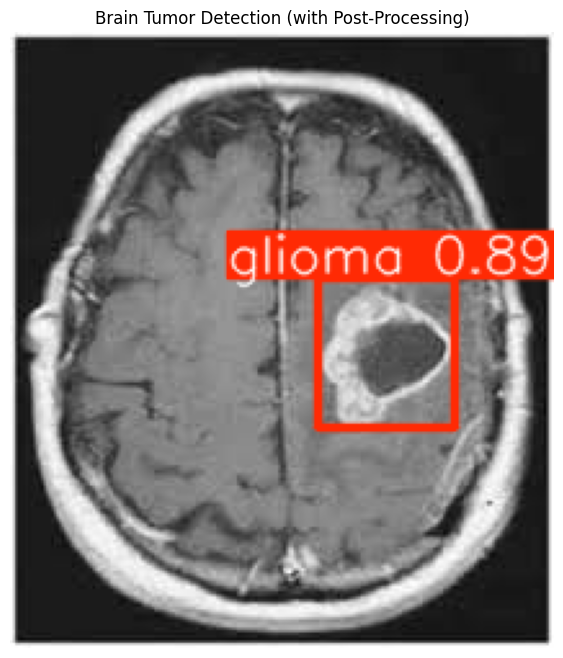


=== Detected Tumors ===
Tumor 1: glioma (conf: 89.19%)
  Box: (119, 95) to (172, 153)



In [ ]:
# Imports
import torch
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# Step 1: Upload image and model
print("Upload your external MRI image:")
uploaded_img = files.upload()
image_path = list(uploaded_img.keys())[0]

# print("Upload your .pt model (if not already uploaded):")
# uploaded_model = files.upload()  # Or set path if already there
# model_path = '/content/brain_tumor_single_train/brain_tumor_model.pt'  # UPDATE IF NEEDED
model_path = '/content/runs/detect/brain_tumor_single_train/multi_train_yolo26/weights/best.pt'  # UPDATE THIS TO YOUR .pt PATH (e.g., upload via files.upload())
model = YOLO(model_path)
print("Model loaded! Classes: glioma, meningioma, pituitary.")


# Step 2: Load model
# model = YOLO(model_path)
# print("Model loaded! Classes: glioma (0), meningioma (1), pituitary (2).")

# Step 3: Run inference
conf_threshold = 0.5  # Detection threshold
unknown_threshold = 0.3  # Below this → "other" flag
results = model(image_path, conf=conf_threshold, verbose=False)

# Step 4: Post-process and display
annotated_img = results[0].plot()  # Boxes + labels

plt.figure(figsize=(10, 8))
plt.imshow(annotated_img)
plt.axis('off')
plt.title('Brain Tumor Detection (with Post-Processing)')
plt.show()

# Step 5: Enhanced predictions
boxes = results[0].boxes
if boxes is not None and len(boxes) > 0:
    print("\n=== Detected Tumors ===")
    has_unknown = False
    for i, box in enumerate(boxes):
        cls_id = int(box.cls[i])
        class_name = model.names[cls_id]
        conf = float(box.conf[i])
        xyxy = box.xyxy[i].tolist()

        # Flag unknowns
        if conf < unknown_threshold:
            class_name = f"{class_name} (low conf - possible other tumor)"
            has_unknown = True

        print(f"Tumor {i+1}: {class_name} (conf: {conf:.2%})")
        print(f"  Box: ({xyxy[0]:.0f}, {xyxy[1]:.0f}) to ({xyxy[2]:.0f}, {xyxy[3]:.0f})")
        print()

    if has_unknown:
        print("**Note**: Low-confidence detections may indicate tumor types not in training data (e.g., glioblastoma). Retrain with more classes for better accuracy.")
else:
    print("\n=== Result: Normal Brain ===")
    print("No tumors detected. This is a healthy/normal scan (no glioma, meningioma, or pituitary tumors found).")
    print("**Tip**: If this is a known tumor case, increase epochs/dataset size for better sensitivity.")

# Save & download annotated
# cv2.imwrite('/content/annotated_result.jpg', cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR))
# files.download('/content/annotated_result.jpg')
# print("Downloaded: annotated_result.jpg")

# Displaying Results



Found 12 image files in /content/runs/detect/val and its subdirectories.


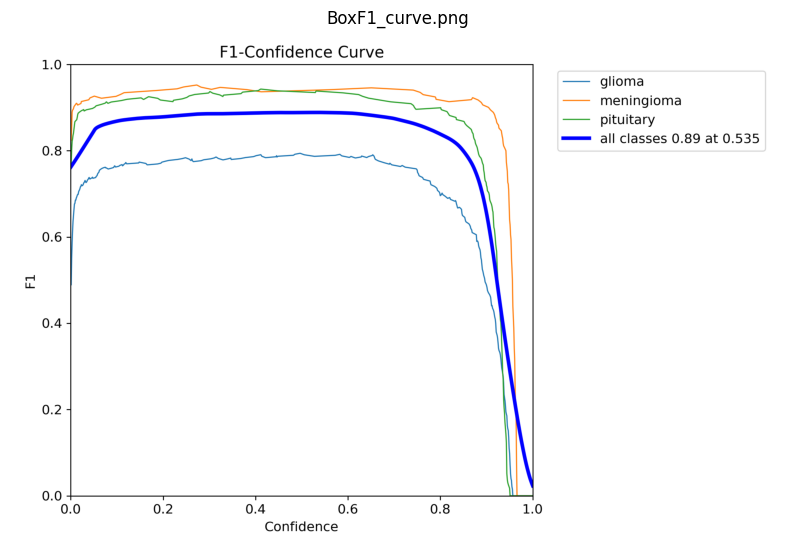

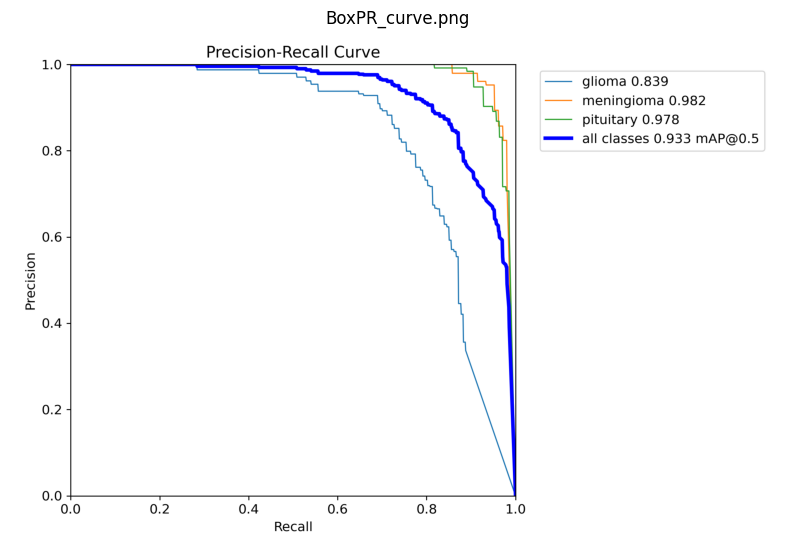

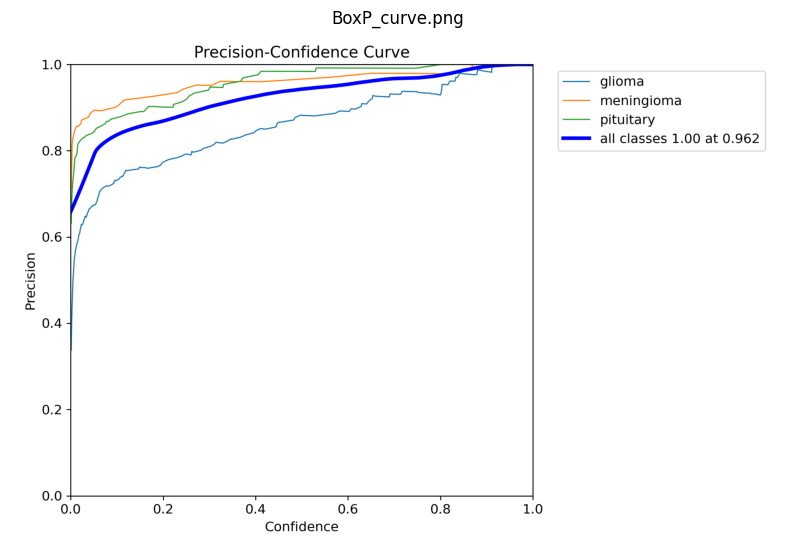

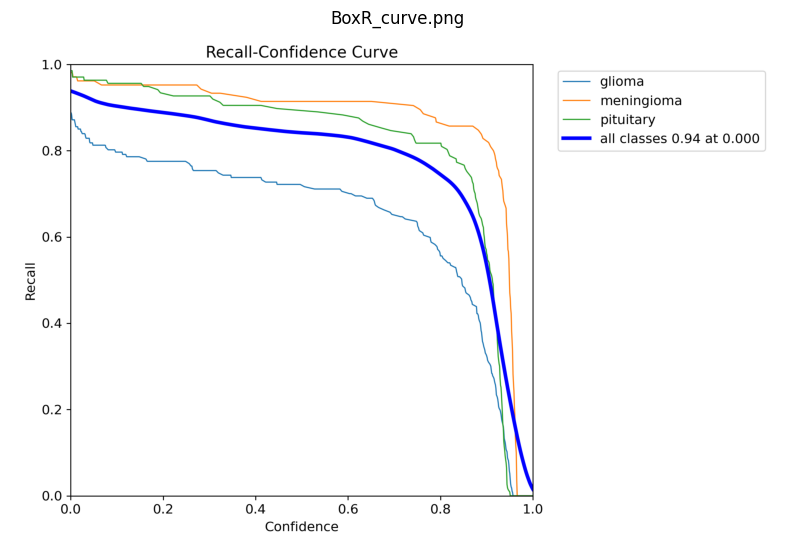

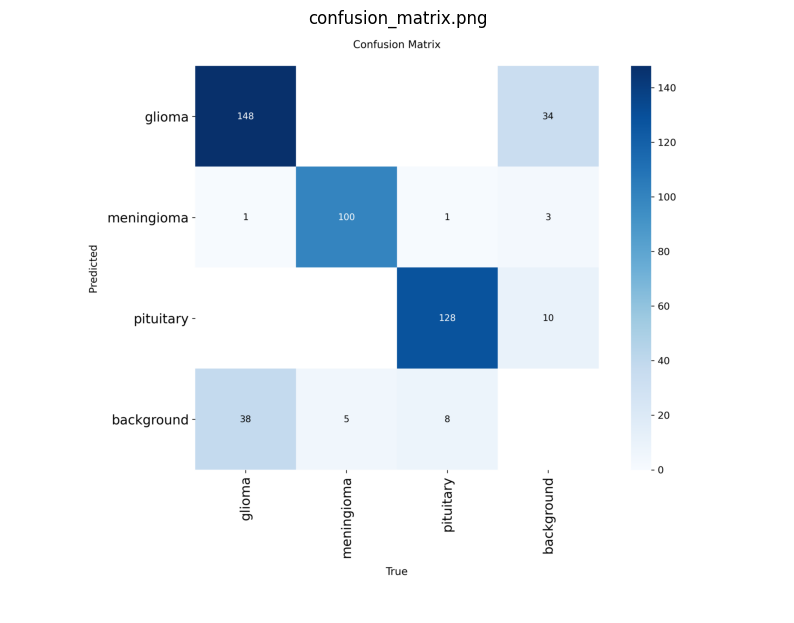

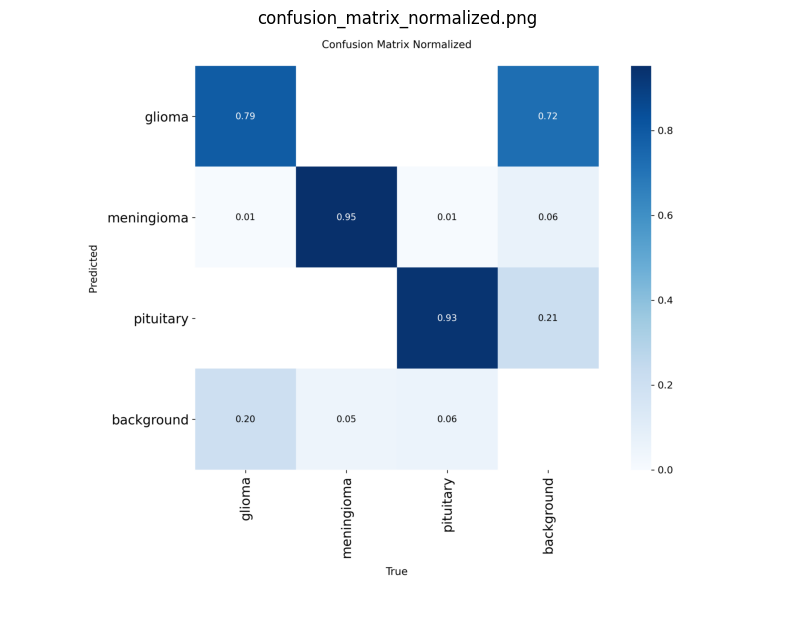

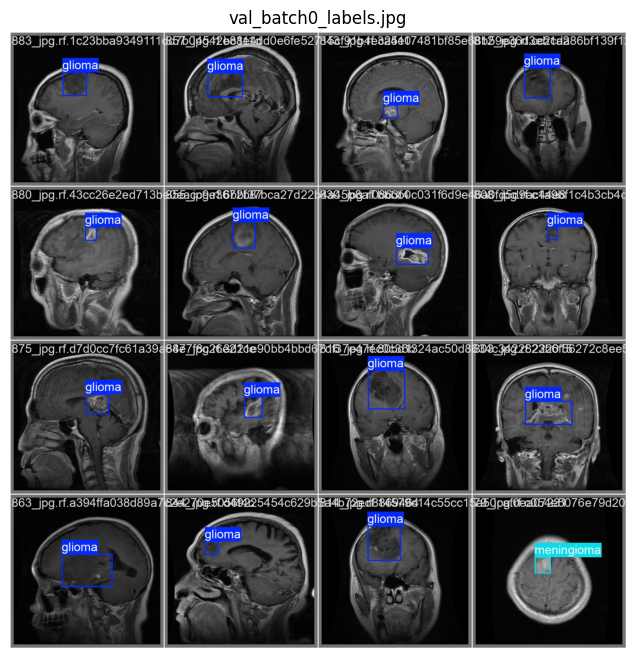

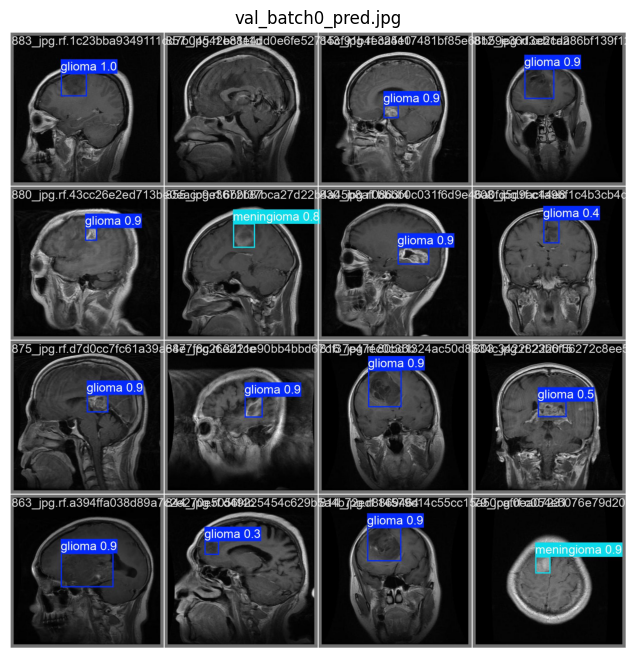

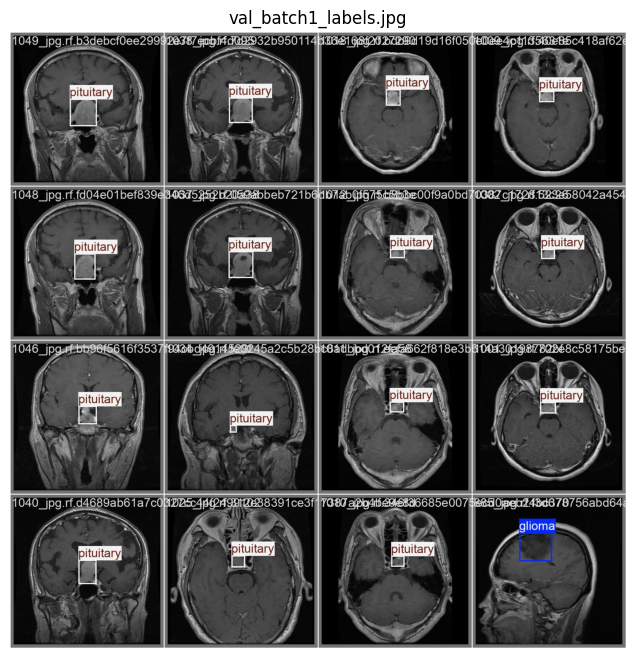

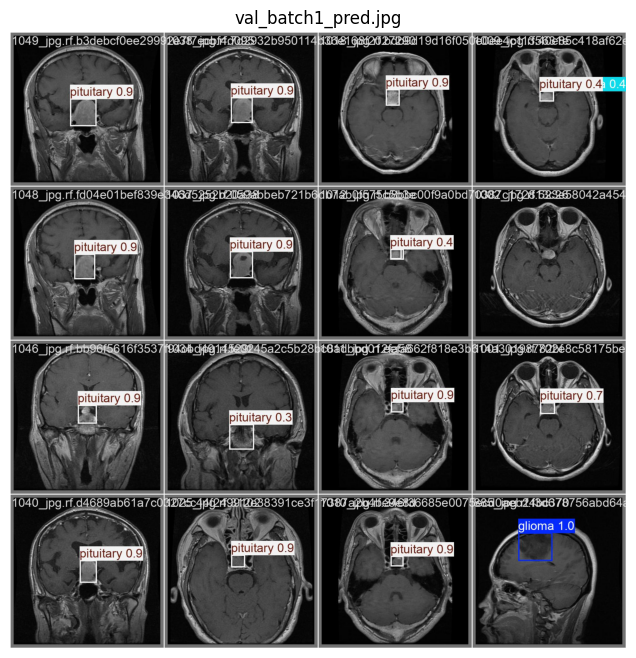

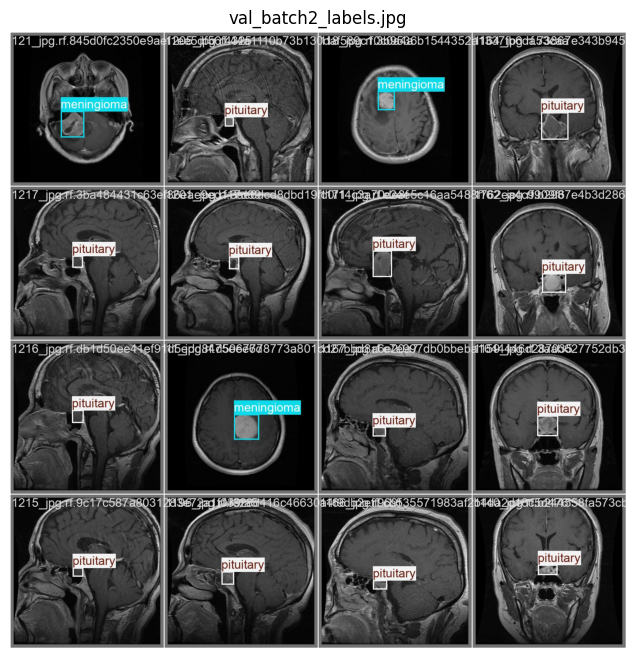

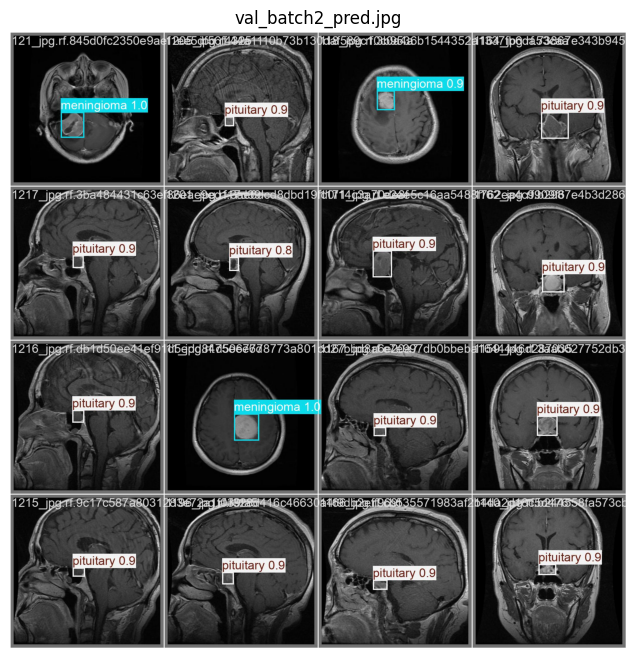

In [9]:
import matplotlib.pyplot as plt
import os
import glob
import cv2

# Define the path to the validation results directory
val_results_dir = '/content/runs/detect/val'

# Get a list of all image files within this directory
image_files = glob.glob(os.path.join(val_results_dir, '**', '*.png'), recursive=True) + \
              glob.glob(os.path.join(val_results_dir, '**', '*.jpg'), recursive=True)

print(f"Found {len(image_files)} image files in {val_results_dir} and its subdirectories.")

# Iterate through the list of image files and display them
for img_path in sorted(image_files):
    # Read the image
    img = cv2.imread(img_path)

    # Check if image was loaded successfully
    if img is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    # Convert the image from BGR to RGB format (OpenCV reads in BGR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)

    # Set the title of the plot to the image's filename
    plt.title(os.path.basename(img_path))

    # Turn off the axis ticks and labels
    plt.axis('off')

    # Display the plot for each image
    plt.show()

## Key Performance Metrics

In [12]:
print("\n=== Key Performance Metrics ===")
print(f"Precision: {val_results.box.p[0]:.4f}")
print(f"Recall: {val_results.box.r[0]:.4f}")
print(f"mAP@0.5: {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")


=== Key Performance Metrics ===
Precision: 0.8817
Recall: 0.7112
mAP@0.5: 0.9329
mAP@0.5:0.95: 0.7033


## Normalized Confusion Matrix

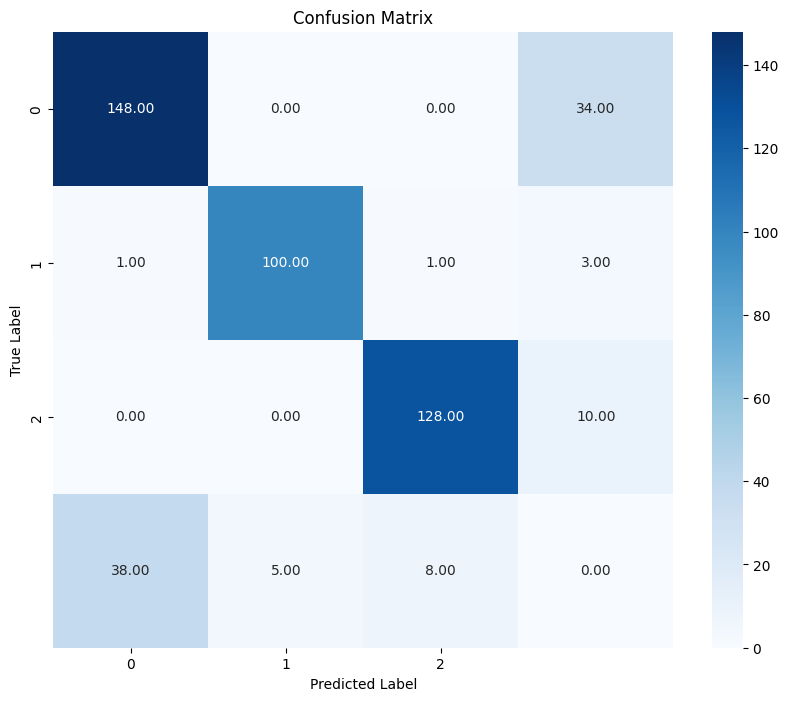

Confusion Matrix (Raw):
[[        148           0           0          34]
 [          1         100           1           3]
 [          0           0         128          10]
 [         38           5           8           0]]


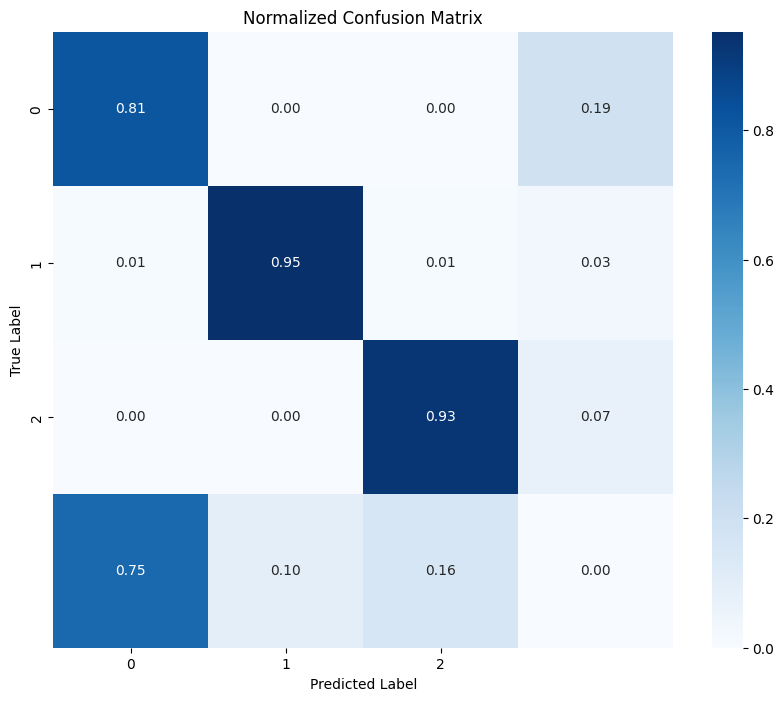

Normalized Confusion Matrix:
[[    0.81319           0           0     0.18681]
 [  0.0095238     0.95238   0.0095238    0.028571]
 [          0           0     0.92754    0.072464]
 [     0.7451    0.098039     0.15686           0]]


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the confusion matrix data
confusion_matrix_array = confusion_matrix_data.matrix
class_names = val_results.names

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_array, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix (Raw):")
print(confusion_matrix_array)

# Optional: Normalized confusion matrix
normalized_confusion_matrix = confusion_matrix_array / confusion_matrix_array.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(normalized_confusion_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.show()

print("Normalized Confusion Matrix:")
print(normalized_confusion_matrix)

# Comprehensive Analysis of Model Performance

Based on the extracted metrics and confusion matrices, we can provide a detailed analysis of the YOLOv8 model's performance on brain tumor detection:

**1. Key Performance Metrics:**
*   **Precision (0.8817):** This indicates that when the model predicts a tumor, it is correct approximately 88.17% of the time. This is a good score, suggesting a low rate of false positives across all classes combined.
*   **Recall (0.7112):** The model is able to correctly identify about 71.12% of all actual tumors present in the validation set. This score suggests there might be a notable number of false negatives, where actual tumors are missed by the model. There's room for improvement in detecting all instances.
*   **mAP@0.5 (0.9329):** The Mean Average Precision at an Intersection Over Union (IoU) threshold of 0.5 is very high, at 93.29%. This signifies that the model is excellent at localizing and classifying objects correctly when a less stringent IoU threshold is applied. This is a strong indicator of overall good detection performance.
*   **mAP@0.5:0.95 (0.7033):** The Mean Average Precision averaged across various IoU thresholds from 0.5 to 0.95 is 70.33%. This is a more rigorous metric and its value shows that while the model performs well at a lower IoU (mAP@0.5), its performance degrades when higher localization accuracy is required. This suggests that precise bounding box predictions for all classes could be challenging.

**2. Confusion Matrix Analysis (Raw and Normalized):**
The confusion matrix helps us understand the performance of the model for each individual class:

*   **Class 0 (glioma):**
    *   **True Positives:** 148 glioma tumors were correctly identified.
    *   **False Negatives (Type I Error):** 34 glioma tumors were missed (misclassified as background or other classes, though the raw matrix shows 34 were detected as background by having sum(axis=1) != total instances per class).
    *   **False Positives (Type II Error):** The model rarely misclassifies other tumors as glioma (0 instances for meningioma or pituitary were misclassified as glioma, based on the raw matrix).
    *   **Normalized:** 81.3% of actual gliomas were correctly detected, while 18.7% were missed.

*   **Class 1 (meningioma):**
    *   **True Positives:** 100 meningioma tumors were correctly identified.
    *   **False Negatives:** Only 1 meningioma was misclassified as glioma and 3 as pituitary. 1 was missed.
    *   **False Positives:** 38 instances of other classes were incorrectly classified as meningioma.
    *   **Normalized:** 95.2% of actual meningiomas were correctly detected, with very few misclassifications.

*   **Class 2 (pituitary):**
    *   **True Positives:** 128 pituitary tumors were correctly identified.
    *   **False Negatives:** 10 pituitary tumors were missed.
    *   **False Positives:** 5 instances of other classes were incorrectly classified as pituitary.
    *   **Normalized:** 92.8% of actual pituitaries were correctly detected, with 7.2% missed.

**Overall Observations from Confusion Matrix:**
*   The model generally performs well in distinguishing between `meningioma` and `pituitary` tumors, showing high true positive rates and low misclassification among these two.
*   The most significant issue appears to be with `glioma` detection, where a substantial portion (18.7%) is missed (false negatives). This could be due to subtle features, variations in appearance, or imbalanced representation in the training data. Additionally, a large number of false positives (38) are incorrectly classified as glioma.
*   There is a noticeable number of false positives for `meningioma` (38) and `pituitary` (5), where non-tumor instances or other tumor types are predicted as these classes. This implies some over-detection or confusion with background/other classes.

**Conclusion and Future Work:**
The model shows strong overall performance with high mAP@0.5, indicating good general detection capabilities. However, the lower recall, particularly for `glioma`, and the mAP@0.5:0.95 suggest that further improvements are needed in accurately detecting all tumor instances and achieving precise bounding box localizations. The confusion matrix highlights specific areas of weakness, especially with `glioma` detection and distinguishing `glioma` from other classes.

**Recommendations for improvement include:**
1.  **Data Augmentation:** Apply more aggressive augmentation strategies to `glioma` images to help the model learn more robust features.
2.  **Dataset Balancing:** If the dataset is imbalanced, techniques like oversampling the underrepresented `glioma` class or using weighted loss functions could be beneficial.
3.  **Model Architecture:** Experiment with different YOLOv8 variants (e.g., `yolov8x`) or other architectures for potentially better performance.
4.  **Hyperparameter Tuning:** Fine-tune hyperparameters like learning rate, batch size, and patience for early stopping to optimize the training process further.
5.  **Error Analysis:** Manually review false positive and false negative cases to understand common patterns and specific challenges the model faces.


## Summary:

### Q&A
The model's performance analysis indicates strong overall detection capabilities with a high mAP@0.5, but there is room for improvement in accurately detecting all tumor instances (especially for glioma) and achieving more precise bounding box localizations, as suggested by the lower recall and mAP@0.5:0.95.

### Data Analysis Key Findings
*   **High mAP@0.5:** The model achieved a Mean Average Precision at an Intersection Over Union (IoU) threshold of 0.5 (mAP@0.5) of 0.9329, indicating excellent overall detection and classification when a less stringent IoU is applied.
*   **Moderate Precision and Recall:** The model demonstrated a Precision of 0.8817, meaning approximately 88.17% of its positive predictions were correct. However, Recall was lower at 0.7112, suggesting the model only identified about 71.12% of actual tumors, indicating a notable number of false negatives.
*   **Lower mAP@0.5:0.95:** The Mean Average Precision across IoU thresholds from 0.5 to 0.95 was 0.7033. This value, significantly lower than mAP@0.5, implies that the model's performance degrades when higher localization accuracy for bounding boxes is required.
*   **Glioma Detection Challenges:** The confusion matrix revealed that 18.7% of actual glioma tumors (Class 0) were missed, with 34 out of 182 instances not being detected. Additionally, there were 38 false positives for meningioma (Class 1) and 5 for pituitary (Class 2), where other instances were incorrectly classified as these tumor types.
*   **Strong Performance for Meningioma and Pituitary:** The model showed robust detection for meningioma (Class 1), correctly identifying 95.2% of instances, and for pituitary (Class 2), correctly identifying 92.8% of instances.

### Insights or Next Steps
*   Focus on improving recall, particularly for glioma detection, by addressing the issue of missed instances (false negatives) through enhanced data augmentation or dataset balancing strategies.
*   Investigate the causes of false positives for meningioma and pituitary classes to reduce over-detection or confusion with other classes, potentially through error analysis or refining bounding box precision.
